In [12]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
!ls /content/drive/MyDrive


'221030240 Utkarsh Sood.pdf'   class12.pdf	   morph_project
'class10 (1).pdf'	      'Colab Notebooks'    PORTFOLIO
 class10.pdf		      'MOOC Courses.pdf'  'Wheebox employability test'


In [14]:
!ls /content/drive/MyDrive/morph_project


datasets  efficientnet_b3_casia.pth  models


In [ ]:
!ls /content/drive/MyDrive/morph_project/datasets


'archive (1).zip'


In [8]:
!mkdir -p /content/morph_project/data


In [9]:
!cp "/content/drive/MyDrive/morph_project/datasets/archive (1).zip" "/content/morph_project/data/casia.zip"
print("✅ Copied archive to Colab")



✅ Copied archive to Colab


In [10]:
import zipfile

zip_path = "/content/morph_project/data/casia.zip"
extract_path = "/content/morph_project/data/images"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted to:", extract_path)


✅ Dataset extracted to: /content/morph_project/data/images


In [ ]:
!ls /content/morph_project/data/images


CASIA2


In [15]:
import os, pandas as pd
from sklearn.model_selection import train_test_split

image_paths = []
labels = []

root = "/content/morph_project/data/images/CASIA2"

for root_dir, _, files in os.walk(root):
    for f in files:
        if f.lower().endswith(("jpg","jpeg","png","bmp")):
            full_path = os.path.join(root_dir, f)
            image_paths.append(full_path)

            # If folder has 'Au' = bonafide (0), otherwise 'Tp' = attack (1)
            if "/Au" in root_dir or "\\Au" in root_dir:
                labels.append(0)
            else:
                labels.append(1)

df = pd.DataFrame({"path": image_paths, "label": labels})

df_train, df_temp = train_test_split(df, test_size=0.2, stratify=df.label, random_state=42)
df_val, df_test = train_test_split(df_temp, test_size=0.5, stratify=df_temp.label, random_state=42)

os.makedirs("/content/morph_project/data/csv", exist_ok=True)
df_train.to_csv("/content/morph_project/data/csv/train.csv", index=False)
df_val.to_csv("/content/morph_project/data/csv/val.csv", index=False)
df_test.to_csv("/content/morph_project/data/csv/test.csv", index=False)

print("✅ CSVs created")
print("Train:", len(df_train), "Val:", len(df_val), "Test:", len(df_test))


✅ CSVs created
Train: 11742 Val: 1468 Test: 1468


In [17]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch
from torch.utils.data import Dataset, DataLoader
import cv2

class CASIADataset(Dataset):
    def __init__(self, df, transforms):
        self.paths = df['path'].values
        self.labels = df['label'].values
        self.transforms = transforms

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = self.transforms(image=img)['image']
        label = torch.tensor(self.labels[idx]).long()
        return img, label

df_train = pd.read_csv("/content/morph_project/data/csv/train.csv")
df_val = pd.read_csv("/content/morph_project/data/csv/val.csv")
df_test = pd.read_csv("/content/morph_project/data/csv/test.csv")

train_tf = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=20, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_tf = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

train_loader = DataLoader(CASIADataset(df_train, train_tf), batch_size=32, shuffle=True)
val_loader   = DataLoader(CASIADataset(df_val, val_tf), batch_size=32)
test_loader  = DataLoader(CASIADataset(df_test, val_tf), batch_size=32)

print("✅ Dataloaders ready")


✅ Dataloaders ready


In [18]:
import timm
import torch.nn as nn

device = "cuda" if torch.cuda.is_available() else "cpu"

model = timm.create_model("vit_base_patch16_224", pretrained=True)
model.head = nn.Linear(model.head.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print("✅ ViT Model ready on", device)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

✅ ViT Model ready on cpu


In [ ]:
from tqdm import tqdm

def train_one_epoch(model, loader):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for imgs, labels in tqdm(loader):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / len(loader), correct / total


In [ ]:
@torch.no_grad()
def validate(model, loader):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / len(loader), correct / total


In [ ]:
EPOCHS = 7

for epoch in range(EPOCHS):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    v_loss, v_acc = validate(model, val_loader)

    print(f"\n📌 Epoch {epoch+1}/{EPOCHS}")
    print(f"✅ Train Acc: {tr_acc*100:.2f}%  | Loss: {tr_loss:.4f}")
    print(f"✅ Val   Acc: {v_acc*100:.2f}%  | Loss: {v_loss:.4f}")


100%|██████████| 367/367 [07:00<00:00,  1.15s/it]



📌 Epoch 1/7
✅ Train Acc: 86.31%  | Loss: 0.3087
✅ Val   Acc: 86.99%  | Loss: 0.3266


100%|██████████| 367/367 [06:55<00:00,  1.13s/it]



📌 Epoch 2/7
✅ Train Acc: 88.17%  | Loss: 0.2605
✅ Val   Acc: 61.24%  | Loss: 0.5783


100%|██████████| 367/367 [06:55<00:00,  1.13s/it]


...


📌 Epoch 5/7
✅ Train Acc: 90.58%  | Loss: 0.2121
✅ Val   Acc: 88.76%  | Loss: 0.2566


100%|██████████| 367/367 [06:55<00:00,  1.13s/it]



📌 Epoch 6/7
✅ Train Acc: 90.99%  | Loss: 0.2021
✅ Val   Acc: 87.87%  | Loss: 0.3045


100%|██████████| 367/367 [06:55<00:00,  1.13s/it]



📌 Epoch 7/7
✅ Train Acc: 91.36%  | Loss: 0.1911
✅ Val   Acc: 88.90%  | Loss: 0.3210


In [ ]:
# Create folder in Drive if not exists
!mkdir -p /content/drive/MyDrive/morph_project/models

SAVE_PATH = "/content/drive/MyDrive/morph_project/models/vit_casia.pth"
torch.save(model.state_dict(), SAVE_PATH)

print("✅ Model saved permanently at:", SAVE_PATH)


✅ Model saved permanently at: /content/drive/MyDrive/morph_project/models/vit_casia.pth


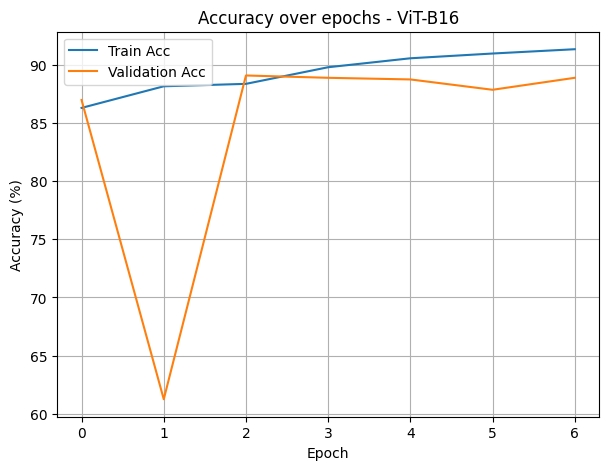

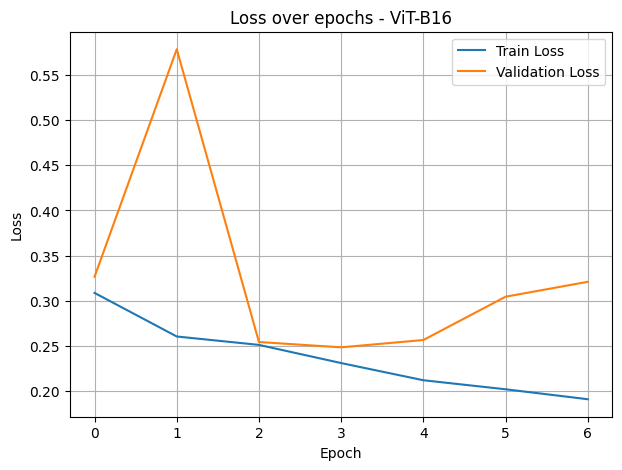

In [ ]:
import matplotlib.pyplot as plt

# We captured accuracy/loss manually from logs (create arrays):
train_accs = [86.31, 88.17, 88.38, 89.81, 90.58, 90.99, 91.36]
val_accs   = [86.99, 61.24, 89.10, 88.90, 88.76, 87.87, 88.90]

train_losses = [0.3087, 0.2605, 0.2512, 0.2311, 0.2121, 0.2021, 0.1911]
val_losses   = [0.3266, 0.5783, 0.2544, 0.2485, 0.2566, 0.3045, 0.3210]

# Accuracy plot
plt.figure(figsize=(7,5))
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Validation Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy over epochs - ViT-B16")
plt.grid(True)
plt.legend()
plt.show()

# Loss plot
plt.figure(figsize=(7,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over epochs - ViT-B16")
plt.grid(True)
plt.legend()
plt.show()


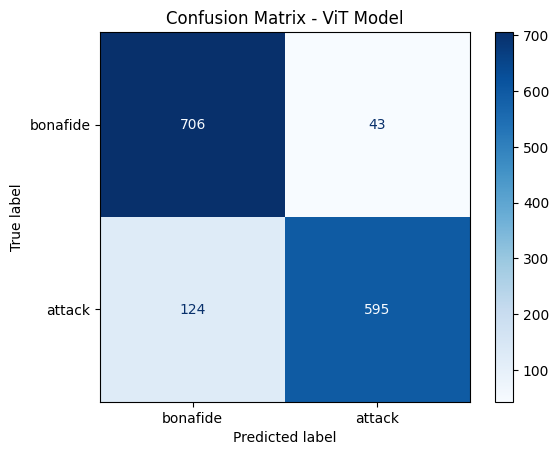

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().tolist())
        y_pred.extend(preds.cpu().tolist())

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["bonafide","attack"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - ViT Model")
plt.show()


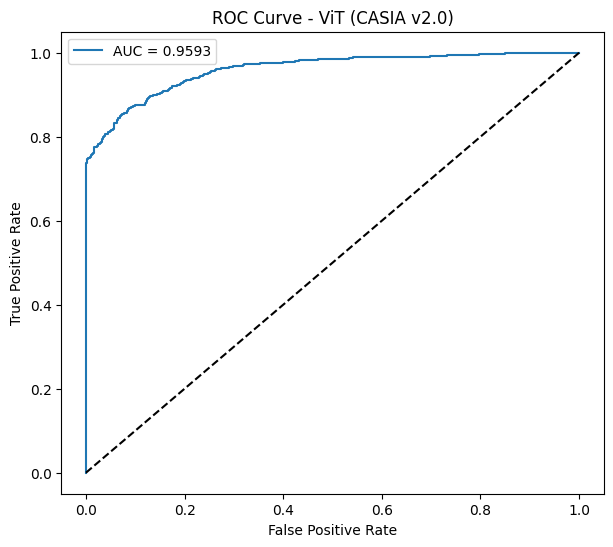

✅ ROC-AUC: 0.9593393880760811


In [ ]:
from sklearn.metrics import roc_curve, auc
import numpy as np

y_scores = []
y_true = []

model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)
        y_scores.extend(probs[:,1].cpu().numpy())
        y_true.extend(labels.cpu().numpy())

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ViT (CASIA v2.0)")
plt.legend()
plt.show()

print("✅ ROC-AUC:", roc_auc)


In [21]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
    path = filename
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    tf = A.Compose([
        A.Resize(224,224),
        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
        ToTensorV2()
    ])

    tensor = tf(image=img)['image'].unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)
        probs = torch.softmax(output, dim=1)[0]
        pred = torch.argmax(probs).item()

    label = "bonafide" if pred==0 else "attack"
    confidence = round(float(probs[pred])*100, 2)

    print(f"Image: {filename}")
    print("Prediction:", label)
    print("Confidence:", confidence, "%")


Saving img0.1.png to img0.1 (1).png
Image: img0.1 (1).png
Prediction: attack
Confidence: 62.63 %
